# PQD Classifier. Training, Saving, Loading, Evaluating and TFLite Converting

***TODO*** Decide wether all imports should be made here or separately Import project libraries

In [1]:
import sys
print(sys.version)

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [2]:
import numpy as np
import scipy as sp

from scipy.io import loadmat

from IPython.display import display
from matplotlib import pyplot as plt
import matplotlib as mpl

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import Sequential
# Conv2D, MaxPooling2D
from tensorflow.keras.layers import Conv1D, MaxPool1D, BatchNormalization, GlobalMaxPooling1D, Flatten, Dense

from keras.utils import plot_model
from keras import regularizers

Dataset signal properties defines for file saving and uploading

In [3]:
# Adjust the following according to dataset
NUM_OF_PQD = 16
NUM_SIGNALS_PER_PQD = 480
FREQUENCY = 50
NUM_OF_CYCLES = 10
NOISE = False

SAMPLING_RATE = 3200

# Signal period = (1/50) * 10 = 200 ms
# Signal samples = 0.2 / (1/3200) = 640 samples
# Probably not needed
NUM_OF_FEATURES = (NUM_OF_CYCLES / FREQUENCY) * SAMPLING_RATE

BASE_FILENAME = str(NUM_OF_PQD) + 'pqd_' + str(NUM_SIGNALS_PER_PQD) + 'pattern_' + str(FREQUENCY) + 'hz_' + str(NUM_OF_CYCLES) + 'cycle_'

if NOISE:
    BASE_FILENAME += 'withNoise'
else:
    BASE_FILENAME += 'noNoise'

Datasets and models should be generated with a meaningful name, including how many PQD types and how much signals per PQD type are there.

Dataset generator's sampling rate is 3.2 kHz, frequency can be ser to 50 or 60 Hz.
Example dataset's number of cycles is 10 and nominal frequency is 50 Hz.

In [4]:
BASE_FILENAME

'16pqd_480pattern_50hz_10cycle_noNoise'

## 1) Import Dataset

***TODO*** How does cross-validation perform in this use case?

In [5]:
# Adjust the following according to dataset
split_percentage = 0.90

databaseLength = NUM_OF_PQD * NUM_SIGNALS_PER_PQD
trainBound = int(databaseLength * split_percentage)
validateBound = trainBound + 1

DATASET_FILENAME = BASE_FILENAME + '.mat'

In [6]:
DataBase = loadmat(DATASET_FILENAME)
X = [None]
Y = [None]

for i in range(databaseLength):
    # File [Workspace Variable] 1x7680 [Field]
    X.append(DataBase ['SignalsDataBase'][0][i]['signals'][0])
    Y.append(DataBase ['SignalsDataBase'][0][i]['labels'][0])

#(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train = np.array(X[1:trainBound])

# Adds a new dimension at the last axis.
# This transforms the signals into the format expected by deep-learning layers
X_train = np.expand_dims(X_train, axis=-1)

# Retrieves the size of the second dimension of X_train.
# This is the number of samples for signal (640)
#numOfFeatures = X_train.shape[1]

Y_train = np.reshape(np.array(Y[1:trainBound]), (trainBound - 1, 1))

X_validate = np.array(X[validateBound:])
X_validate = np.expand_dims(X_validate, axis=-1)
Y_validate = np.array(Y[validateBound:])
Y_validate = np.reshape(Y_validate, (len(Y) - validateBound, 1))

In [7]:
X_validate.shape[0]

768

Bibliography creates dataset using 64 bit float variables

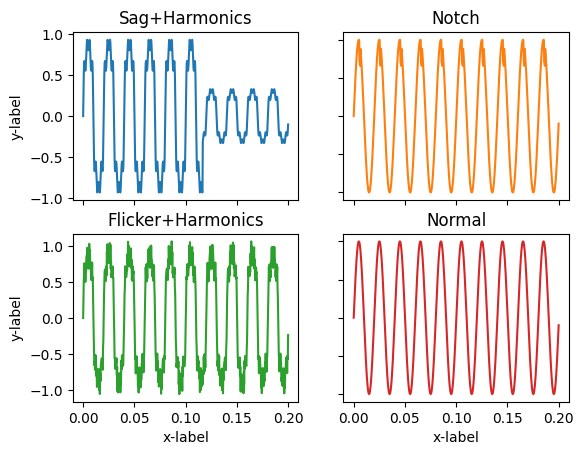

In [8]:
# https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html
t = np.linspace(0, 0.2, 640)

fig, axs = plt.subplots(2, 2)
axs[0, 0].plot(t, X[10])
axs[0, 0].set_title(Y[10])
axs[0, 1].plot(t, X[11], 'tab:orange')
axs[0, 1].set_title(Y[11])
axs[1, 0].plot(t, X[12], 'tab:green')
axs[1, 0].set_title(Y[12])
axs[1, 1].plot(t, X[13], 'tab:red')
axs[1, 1].set_title(Y[13])

for ax in axs.flat:
    ax.set(xlabel='x-label', ylabel='y-label')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()

In [9]:
# Make OneHot classes :
# Convert categorical labels into binary format for model output
from sklearn.preprocessing import OneHotEncoder#,LabelEncoder

OHE = OneHotEncoder()
#y_test_OneHot = OHE.fit_transform(y_test).toarray()
Y_train_OneHot = OHE.fit_transform(Y_train).toarray()
Y_validate_OneHot = OHE.fit_transform(Y_validate).toarray()

# print(OHE.categories_)

## 2) Train a Deep CNN

***TODO*** Scheduler function can be implemented using built-in optimizer schedules like ExponentialDecay, epoch-based callbacks like LearningRateScheduler, or performance-based callbacks like ReduceLROnPlateau. (Google search)

In [10]:
def scheduler(epoch):
    """
    Compute the learning rate for the current epoch
    """
    dropEvery = 10
    initAlpha = 0.01
    factor = 0.5
    exp = np.floor((1 + epoch) / dropEvery)
    alpha = initAlpha * (factor ** exp)
    # return the learning rate
    print('lr =', alpha)
    return float(alpha)

In [11]:
base_model = Sequential([
    #Input(shape=(32,32,3,)),

    # UNIT1 #############################################
    # input_shape=(numOfFeatures,1)
    
    # Conv1:
    # Conv2:
    # Pool1:
    # BN1:
    # UNIT2 #####################################
    # Conv3:
    # Conv4:
    # Pool2:
    # BN2:
    # UNIT3 ####################################
    # Conv5:
    # Conv6:
    # Pool3:
    # BN4:
    
    # Fully Connected Part ####################################
    
    # Dense1:
    # Dense2:
    # BN3:
    # Dense3:
    
    Conv1D(filters=32, kernel_size=3, strides=1, activation='relu'),
    Conv1D(filters = 32, kernel_size=3, strides = 1, activation='relu'),
    MaxPool1D(pool_size=(3), strides = 1), #TODO : data_format='channels_first' ??
    Conv1D(filters = 64, kernel_size=3,strides = 1, activation='relu'),
    Conv1D(filters = 64, kernel_size=3,strides = 1, activation='relu'),
    MaxPool1D(pool_size=(3), strides = 1),
    Conv1D(filters = 128, kernel_size=3,strides = 1, activation='relu'),
    Conv1D(filters = 128, kernel_size=3,strides = 1, activation='relu'),
    GlobalMaxPooling1D(), #TODO : data_format='channels_first' ??
    BatchNormalization(),
    Flatten(),
    Dense(units=256, activation='relu',use_bias=True),
    Dense(units=128, activation='relu',use_bias=True),
    BatchNormalization(),
    Dense(units=16, activation='softmax',use_bias=True)])

# training parameters:
callback = tf.keras.callbacks.LearningRateScheduler(scheduler)

print (base_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ ?                           │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


### Model 1

***TODO*** TFLite model shows additional classes:
ExpandDims and Reshape
Can this be avoided? How to visualize in Keras?

Categorical Cross-Entropy: Use for multi-class predictions with one-hot encoded targets and a softmax output layer.



In [12]:
opt = keras.optimizers.Nadam()

***TODO*** How much batch_size? Hyperparameter tuning? Does overfitting needs to be avoided?

### Model 2

In [ ]:
# https://keras.io/examples/vision/swin_transformers/
opt = keras.optimizers.AdamW(learning_rate=0.0001, weight_decay=0.001)

### Model 3

***TODO*** Separate optimizer from three models to avoid redundancy

In [ ]:
# https://keras.io/examples/vision/swin_transformers/
opt = keras.optimizers.SGD(learning_rate=0.0001, weight_decay=0.001)

lr = 0.01
Epoch 1/43
108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.3202 - loss: 1.7270 - val_accuracy: 0.1042 - val_loss: 24.2685 - learning_rate: 0.0100
lr = 0.01
Epoch 2/43
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.2798 - loss: 1.7215 - val_accuracy: 0.0794 - val_loss: 29.8265 - learning_rate: 0.0100
lr = 0.01
Epoch 3/43
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.4185 - loss: 1.3255 - val_accuracy: 0.1003 - val_loss: 12.7443 - learning_rate: 0.0100
lr = 0.01
Epoch 4/43
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.4383 - loss: 1.2544 - val_accuracy: 0.1706 - val_loss: 7.9421 - learning_rate: 0.0100
lr = 0.01
Epoch 5/43
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.4570 - loss: 1.2237 - val_accuracy: 0.1276 - val_loss: 3.7054 - learning_rate: 0.0100
lr = 0.01
Epoch 6/43
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.5360 - loss: 1.0961 - val_accuracy: 0.1784 - val_loss: 12.6515 - learning_rate: 0.0100
lr = 0.01
Epoch 7/

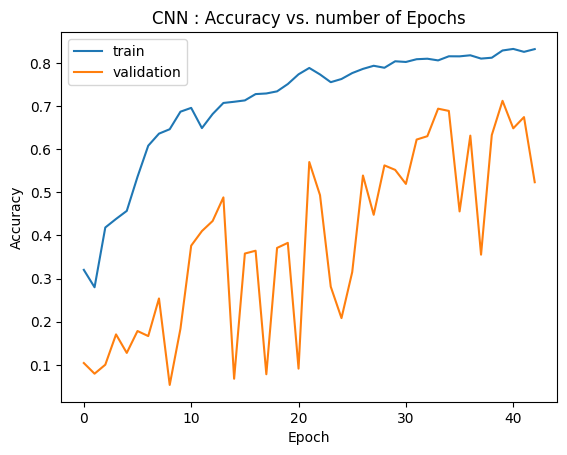

In [13]:
base_model.compile(loss='categorical_crossentropy',
                   optimizer=opt,
                   metrics=['accuracy'])

base_model_history = base_model.fit(X_train, Y_train_OneHot,
                                    batch_size=64,
                                    epochs=43,
                                    callbacks=[callback],
                                    validation_data=(X_validate, Y_validate_OneHot),
                                    verbose=1)

model = base_model

# Plot CNN's accuracy vs. epoch num:
fig = plt.figure()
plt.plot(base_model_history.history['accuracy'])
plt.plot(base_model_history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN : Accuracy vs. number of Epochs')
plt.legend(['train','validation'])
plt.show()

### ***TODO*** Fix visualization, if needed, otherwise, model.summary approach can be used

In [ ]:
!pip install pydot graphviz

In [ ]:
!pip install pydotplus

In [ ]:
from tensorflow.keras import layers, utils

utils.plot_model(
    model, 
    to_file='model_architecture.png', 
    show_shapes=True, 
    show_layer_names=True
)

## 3) File Saving

In [14]:
# Prexis = _MiniBatch_lr
MODEL_FILENAME = BASE_FILENAME + '_NadamOptimised_12'
KERAS_FILENAME = MODEL_FILENAME + '.weights.h5'
JSON_FILENAME = MODEL_FILENAME + '.json'
TFLITE_FILENAME = MODEL_FILENAME + '.tflite'
TFLITE_FLOAT_FILENAME = MODEL_FILENAME + '_floatQuantized.tflite'
TFLITE_QUANT_FILENAME = MODEL_FILENAME + '_intQuantized.tflite'

### Optional. Serialize Model to JSON and Save H5 Model

In [15]:
import json

model_json = base_model.to_json()
with open(JSON_FILENAME, "w") as json_file:
    json_file.write(json.dumps(json.loads(model_json), indent=4))

model.save_weights(KERAS_FILENAME)
print("Saved model to disk")

Saved model to disk


### Optional. Load Model from JSON and Create Model

***TODO*** Unify Pre and Post model variable, user can load or train a model and still run the following code

In [ ]:
json_file = open(JSON_FILENAME, 'r')
loaded_model_json = json_file.read()
json_file.close()

loaded_model = tf.keras.models.model_from_json(loaded_model_json)

# load weights into new model:
loaded_model.load_weights(KERAS_FILENAME)
print("Loaded model from disk")

# evaluate loaded model on test data
loaded_model.compile(loss='categorical_crossentropy', optimizer='SGD', metrics=['accuracy']   )
# Define X_test & Y_test data first
#score = loaded_model.evaluate(X_test, Y_test, verbose=0)
score = loaded_model.evaluate(X_validate, Y_validate_OneHot, verbose=0)
print ("%s: %.2f%%" % (loaded_model.metrics_names[1], score[1]*100))

model = loaded_model

## Inference

In [16]:
score = model.evaluate(X_validate, Y_validate_OneHot, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))

compile_metrics: 52.34%


Met the error once, careful with implementation, is round the best approach?

ValueError: Samples [0] can not be inverted when drop=None and handle_unknown='error' because they contain all zeros

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Prediction: Flicker+Swell , Label: Swell 
DeepCNN prediction is False


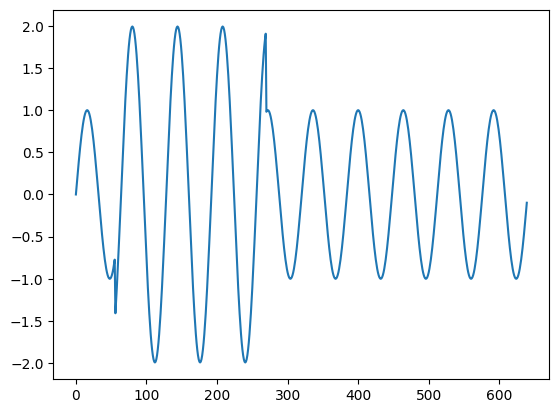

In [17]:
# Given a signal with a disturb 
Xtest = np.array(X_validate[2:3])
Ytest = Y_validate[2:3]
#Xtest = np.expand_dims(Xtest,axis=-1)

XtestPredict = np.round(model.predict(Xtest))
Xtest_label = OHE.inverse_transform(XtestPredict)[0][0]
verdict = (Xtest_label == Ytest[0])
print("Prediction:", Xtest_label , ", Label:" , Ytest[0][0],"\nDeepCNN prediction is",verdict[0])

plt.plot(Xtest[0])
plt.show()

## TFLite Model

In [18]:
import os

def get_file_size(file_path):
    size = os.path.getsize(file_path)
    return size
    
def convert_bytes(size, unit=None):
    if unit == "KB":
        return print('File size: ' + str(round(size / 1024, 3)) + ' Kilobytes')
    elif unit == "MB":
        return print('File size: ' + str(round(size / (1024 * 1024), 3)) + ' Megabytes')
    else:
        return print('File size: ' + str(size) + ' bytes')

Why is there a difference? Previously experiments throwed 2 MB files (they are backed up in other optimizations)

In [19]:
convert_bytes(get_file_size(KERAS_FILENAME), "MB")
keras_model_size = get_file_size(KERAS_FILENAME)

File size: 1.944 Megabytes


### Float conversion

In [20]:
tf_lite_converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = tf_lite_converter.convert()

INFO:tensorflow:Assets written to: C:\Users\nxf93627\AppData\Local\Temp\tmpfi7b21y4\assets


INFO:tensorflow:Assets written to: C:\Users\nxf93627\AppData\Local\Temp\tmpfi7b21y4\assets


Saved artifact at 'C:\Users\nxf93627\AppData\Local\Temp\tmpfi7b21y4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 640, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  2061075298064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061075299216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061075299408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061075300176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061075299600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061075299792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061085213136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061085213712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061075297872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061085212944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  206108

In [21]:
open(TFLITE_FLOAT_FILENAME, "wb").write(tflite_model)

667068

In [22]:
convert_bytes(get_file_size(TFLITE_FLOAT_FILENAME), "KB")
tflite_file_size = get_file_size(TFLITE_FLOAT_FILENAME)

File size: 651.434 Kilobytes


Input shape is overwritten it should be 1

In [23]:
float_interpreter = tf.lite.Interpreter(model_path = TFLITE_FLOAT_FILENAME)
input_details = float_interpreter.get_input_details()
output_details = float_interpreter.get_output_details()
print("Input Shape:", input_details[0]['shape'])
print("Input Type:", input_details[0]['dtype'])
print("Output Shape:", output_details[0]['shape'])
print("Output Type:", output_details[0]['dtype'])

Input Shape: [  1 640   1]
Input Type: <class 'numpy.float32'>
Output Shape: [ 1 16]
Output Type: <class 'numpy.float32'>


C:\Users\nxf93627\.venv-deep-learning\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [24]:
float_interpreter.resize_tensor_input(input_details[0]['index'], ((len(Y) - trainBound - 1), 640, 1))
float_interpreter.resize_tensor_input(output_details[0]['index'], (768, 16))
float_interpreter.allocate_tensors()
input_details = float_interpreter.get_input_details()
output_details = float_interpreter.get_output_details()
print("Input Shape:", input_details[0]['shape'])
print("Input Type:", input_details[0]['dtype'])
print("Output Shape:", output_details[0]['shape'])
print("Output Type:", output_details[0]['dtype'])

Input Shape: [768 640   1]
Input Type: <class 'numpy.float32'>
Output Shape: [768  16]
Output Type: <class 'numpy.float32'>


In [25]:
X_validate.dtype

dtype('<f8')

In [26]:
X_validate_float_numpy = np.array(X_validate, dtype=np.float32)
X_validate_float_numpy.dtype

dtype('float32')

In [28]:
float_interpreter.set_tensor(input_details[0]['index'], X_validate_float_numpy)
float_interpreter.invoke()

tflite_model_predictions = float_interpreter.get_tensor(output_details[0]['index'])
print("Prediction results shape:", tflite_model_predictions.shape)
prediction_classes = np.argmax(tflite_model_predictions, axis=1)
prediction_classes[:50]

Prediction results shape: (768, 16)


array([ 0,  2,  3, 10, 12, 11, 15,  0,  7, 11, 12,  1,  3, 10,  2, 12,  1,
        9,  5,  1, 10, 15,  7,  1, 11,  1,  3,  1, 10,  1,  2, 10, 10, 12,
       10, 10,  3,  2, 12,  9, 10, 15, 12,  9,  3, 10, 10, 12,  3, 11])

In [29]:
print(np.sum(prediction_classes != np.argmax(Y_validate_OneHot, axis=1)), ' / 768')

366  / 768


### Integer converesion

***TODO*** Fix namings

Original shape: (640,) | Dtype: float64
Converted shape: (640,) | Dtype: uint8
Integer Range: Min = 0, Max = 255


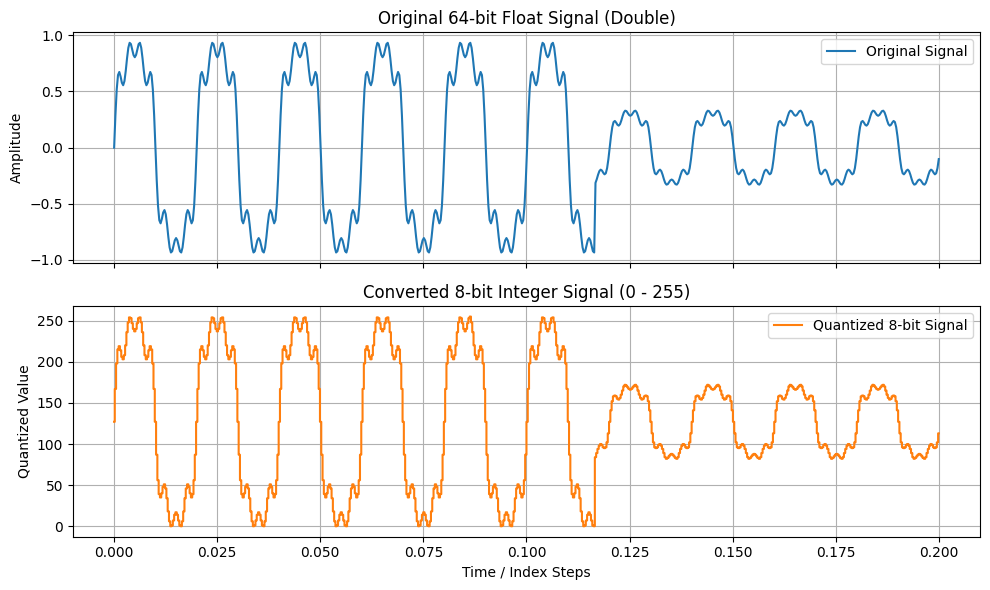

In [30]:
# 2. Normalize and scale the signal to the 8-bit range (0 to 255)
sig_min = X[10].min()
sig_max = X[10].max()
# Linear min-max scaling to 0.0 - 255.0 range
scaled_signal = (X[10] - sig_min) / (sig_max - sig_min) * 255.0

# 3. Convert to 8-bit unsigned integer (uint8)
signal_8 = scaled_signal.astype(np.uint8)

# 4. Print verification metrics
print(f"Original shape: {X[10].shape} | Dtype: {X[10].dtype}")
print(f"Converted shape: {signal_8.shape} | Dtype: {signal_8.dtype}")
print(f"Integer Range: Min = {signal_8.min()}, Max = {signal_8.max()}")

# 5. Visualize and compare the signals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot original continuous signal
ax1.plot(t, X[10], color="tab:blue", label="Original Signal")
ax1.set_title("Original 64-bit Float Signal (Double)")
ax1.set_ylabel("Amplitude")
ax1.grid(True)
ax1.legend()

# Plot quantized 8-bit integer signal
ax2.step(
    t, signal_8, color="tab:orange", where="mid", label="Quantized 8-bit Signal"
)
ax2.set_title("Converted 8-bit Integer Signal (0 - 255)")
ax2.set_xlabel("Time / Index Steps")
ax2.set_ylabel("Quantized Value")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [31]:
tf_lite_converter = tf.lite.TFLiteConverter.from_keras_model(model)
tf_lite_converter.optimizations = [tf.lite.Optimize.DEFAULT]

#def representative_dataset():    
#    for i in range(X_validate):
#        # 2. Normalize and scale the signal to the 8-bit range (0 to 255)
#        sig_min = X_validate[i].min()
#        sig_max = X_validate[i].max()
#        # Linear min-max scaling to 0.0 - 255.0 range
#        scaled_signal = (X_validate[i] - sig_min) / (sig_max - sig_min) * 255.0
#
#        # 3. Convert to 8-bit unsigned integer (uint8)
#        signal_8 = scaled_signal.astype(np.uint8)
#        yield signal_8

def representative_dataset():    
    for i in range(100):
        yield [X_train[i:i+1].astype(np.float32)]

tf_lite_converter.representative_dataset = representative_dataset

tf_lite_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
tf_lite_converter.inference_input_type = tf.uint8
tf_lite_converter.inference_output_type = tf.uint8

tflite_model = tf_lite_converter.convert()

open(TFLITE_QUANT_FILENAME, "wb").write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\nxf93627\AppData\Local\Temp\tmpfcvbgile\assets


INFO:tensorflow:Assets written to: C:\Users\nxf93627\AppData\Local\Temp\tmpfcvbgile\assets


Saved artifact at 'C:\Users\nxf93627\AppData\Local\Temp\tmpfcvbgile'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 640, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  2061075298064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061075299216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061075299408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061075300176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061075299600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061075299792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061085213136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061085213712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061075297872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2061085212944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  206108

C:\Users\nxf93627\.venv-deep-learning\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


200520

In [32]:
convert_bytes(get_file_size(TFLITE_QUANT_FILENAME), "KB")
tflite_file_size = get_file_size(TFLITE_QUANT_FILENAME)

File size: 195.82 Kilobytes


In [33]:
X_validate_numpy_uint8 = (X_validate_float_numpy - X_validate_float_numpy.min()) / (X_validate_float_numpy.max() - X_validate_float_numpy.min())
X_validate_numpy_uint8 *= 255.0
X_validate_uint8 = np.array(X_validate_numpy_uint8, dtype=np.uint8)
X_validate_uint8[:3]

array([[[126],
        [132],
        [135],
        ...,
        [111],
        [116],
        [120]],

       [[126],
        [132],
        [137],
        ...,
        [110],
        [114],
        [121]],

       [[126],
        [132],
        [137],
        ...,
        [110],
        [115],
        [121]]], shape=(3, 640, 1), dtype=uint8)

In [34]:
# https://medium.com/@adityamohiteakm/understanding-post-training-quantization-ptq-for-edge-ai-deployment-a-beginners-guide-with-6d6ba596e8f5

uint8_interpreter = tf.lite.Interpreter(model_path = TFLITE_QUANT_FILENAME)
input_details = uint8_interpreter.get_input_details()
output_details = uint8_interpreter.get_output_details()

uint8_interpreter.resize_tensor_input(input_details[0]['index'], ((len(Y) - trainBound -1), 640, 1))
uint8_interpreter.resize_tensor_input(output_details[0]['index'], ((len(Y) - trainBound -1), 16))

uint8_interpreter.allocate_tensors()

# Prepare input
#X_uint8 = np.expand_dims(X_uint8, axis=0).astype(np.uint8)

#X_uint8 = np.array(X_uint8, dtype=np.uint8)
#X_uint8.dtype

uint8_interpreter.set_tensor(input_details[0]['index'], X_validate_uint8)
uint8_interpreter.invoke()

tflite_model_predictions = uint8_interpreter.get_tensor(output_details[0]['index'])
print("Prediction results shape:", tflite_model_predictions.shape)
prediction_classes = np.argmax(tflite_model_predictions, axis=1)

print(np.sum(prediction_classes != np.argmax(Y_validate_OneHot, axis=1)), ' / 768')

C:\Users\nxf93627\.venv-deep-learning\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Prediction results shape: (768, 16)
724  / 768
